## Exploratory Data Analysis voor klachten train set
### Notebook EDA klachten classificatie voor correcte expertise

### Inhoud

1. [Introductie](#exploratory-data-analysis-voor-klachten-train-set)
2. [Data-Analyse](#data-analyse)
   - [Visualisaties](#visualisaties)
3. ...

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import numpy as np
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

In [48]:
df = pd.read_csv("klacht_train.csv")

### Data Analyse

In [49]:
df.head().T

,0,1,2,3,4
ID,2261475,2054114,2051041,2309270,1620143
Datum_ontvangst,2024-12-23,2024-08-09,2024-08-08,2025-01-24,2023-10-22
Product,Kredietregistratie,Bankrekening,Incasso,Hypotheek,Consumentenkrediet
Omschrijving,My name is not XXXX. \r\nI never lived at XXXX...,In XXXX XXXX I received a notice in the mail s...,A collection agency -- Halsted Financial Servi...,My mortgage was paid off XX/XX/2016 and my esc...,I originally took a loan from Santander on XXX...
Antwoord_bedrijf,Closed with non-monetary relief,Closed with non-monetary relief,Closed with explanation,Closed with explanation,Closed with explanation
Omschrijving_lengte,53,595,309,189,1493
Antwoord_lengte,31,31,23,23,23


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2496 non-null   int64 
 1   Datum_ontvangst      2496 non-null   object
 2   Product              2496 non-null   object
 3   Omschrijving         2496 non-null   object
 4   Antwoord_bedrijf     2496 non-null   object
 5   Omschrijving_lengte  2496 non-null   int64 
 6   Antwoord_lengte      2496 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 136.6+ KB


In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2496.0,1.908198e+06,338003.854903,1290157.0,1602217.50,1935053.5,2208764.25,2470127.0
Omschrijving_lengte,2496.0,1.020137e+03,910.514687,12.0,378.75,710.5,1368.50,4005.0
Antwoord_lengte,2496.0,2.372636e+01,3.967913,6.0,23.00,23.0,23.00,31.0


In [52]:
df['Product'].unique()

array(['Kredietregistratie', 'Bankrekening', 'Incasso', 'Hypotheek',
       'Consumentenkrediet', 'Creditcard'], dtype=object)

In [53]:
df['Antwoord_bedrijf'].unique()

array(['Closed with non-monetary relief', 'Closed with explanation',
       'Closed', 'Closed with monetary relief', 'Untimely response'],
      dtype=object)

In [54]:
df['Datum_ontvangst'].agg(['min', 'max'])

min    2023-03-19
max    2025-04-28
Name: Datum_ontvangst, dtype: object

In [55]:
df.shape
print("De dataset bevat {} rijen en {} kolommen.".format(df.shape[0], df.shape[1]))

De dataset bevat 2496 rijen en 7 kolommen.


In [56]:
# Numeriek
stats_num = df.describe(include='int64').T.reset_index().T
stats_num

,0,1,2
index,ID,Omschrijving_lengte,Antwoord_lengte
count,2496.0,2496.0,2496.0
mean,1908198.351763,1020.137019,23.726362
std,338003.854903,910.514687,3.967913
min,1290157.0,12.0,6.0
25%,1602217.5,378.75,23.0
50%,1935053.5,710.5,23.0
75%,2208764.25,1368.5,23.0
max,2470127.0,4005.0,31.0


In [57]:
# Categorisch
stats_cat = df.describe(include='object').T.reset_index()
stats_cat

,index,count,unique,top,freq
0,Datum_ontvangst,2496,706,2025-01-24,12
1,Product,2496,6,Incasso,707
2,Omschrijving,2496,2494,This debt is not known to me. I recently reque...,2
3,Antwoord_bedrijf,2496,5,Closed with explanation,1955


In [58]:
# Verdeling verschillende expertises binnen de dataset
df['Product'].value_counts()

Product
Incasso               707
Hypotheek             556
Kredietregistratie    536
Creditcard            276
Bankrekening          258
Consumentenkrediet    163
Name: count, dtype: int64

In [59]:
# train-test split 80/20
train, test = train_test_split(df, test_size=0.2, random_state=42)

train.to_csv('klacht_train.csv', index=False)
test.to_csv('klacht_test.csv', index=False)

In [60]:
train.isnull().sum()

ID                     0
Datum_ontvangst        0
Product                0
Omschrijving           0
Antwoord_bedrijf       0
Omschrijving_lengte    0
Antwoord_lengte        0
dtype: int64

In [61]:
train.duplicated().sum()

np.int64(0)

In [62]:
train.drop(columns=['ID']).describe().T

,count,mean,std,min,25%,50%,75%,max
Omschrijving_lengte,1996.0,1013.847194,904.948092,12.0,380.75,709.5,1343.75,4000.0
Antwoord_lengte,1996.0,23.622244,3.975437,6.0,23.00,23.0,23.00,31.0


#### Visualisaties

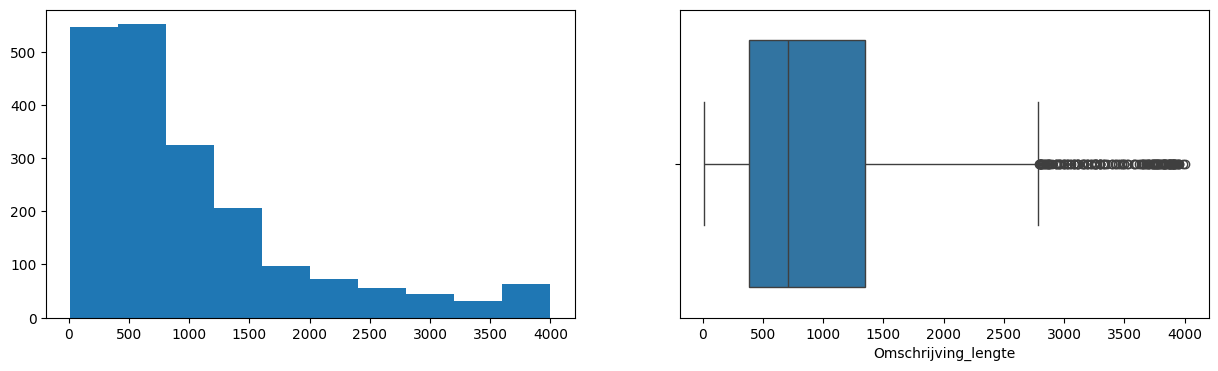

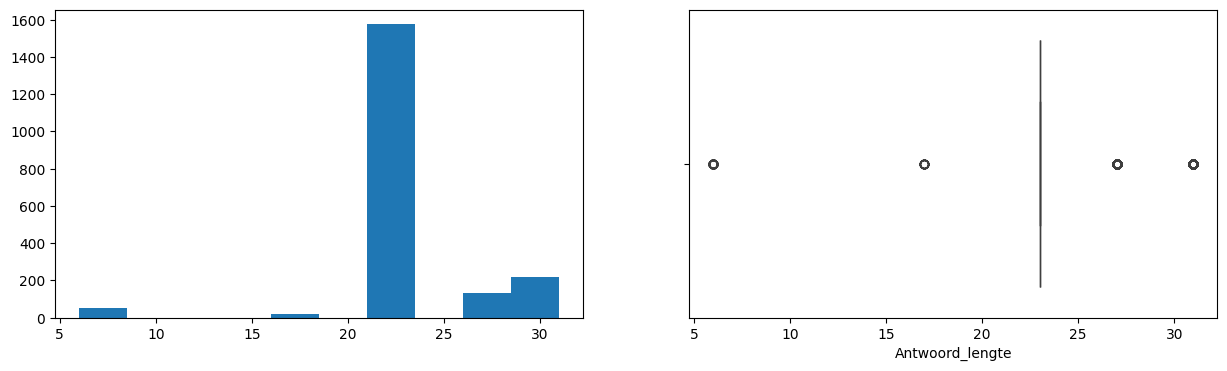

In [63]:
# bepaal numerieke variabelen
num_vars = train.drop(columns=['ID']).select_dtypes(include=np.number).columns.tolist()

# plot de verdeling van elke numerieke variabele in histogram en boxplot
for var in num_vars:
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    plt.hist(train[var])
    plt.subplot(1, 2, 2)
    sns.boxplot(x=train[var])
    plt.show()


In [64]:
train.select_dtypes(include="number").corr()

,ID,Omschrijving_lengte,Antwoord_lengte
ID,1.000000,0.013330,-0.015598
Omschrijving_lengte,0.013330,1.000000,-0.003958
Antwoord_lengte,-0.015598,-0.003958,1.000000


<Axes: >

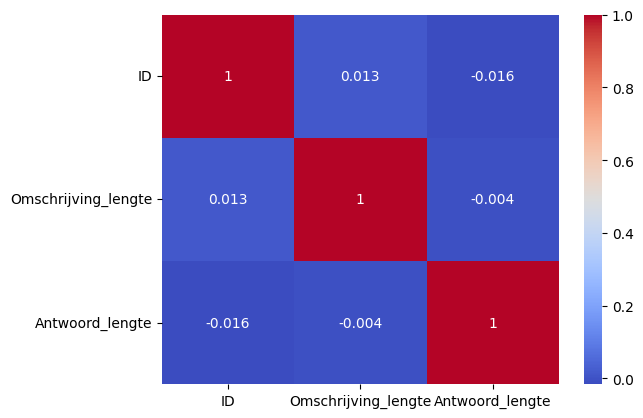

In [65]:
sns.heatmap(train.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")

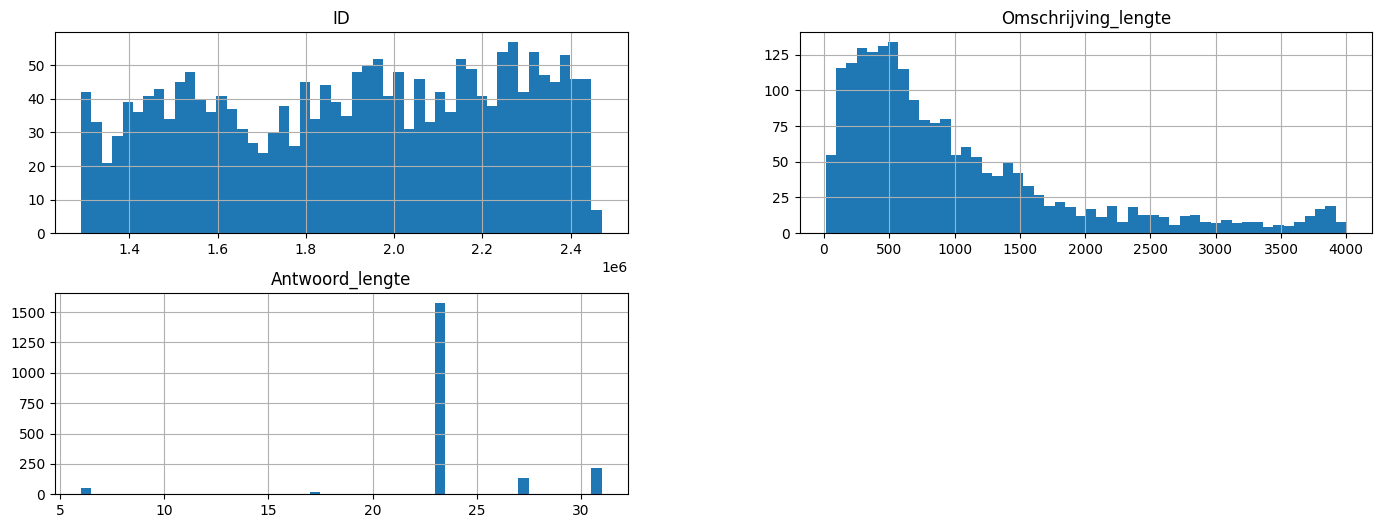

In [66]:
train.hist(bins=50, figsize=(17, 6))
plt.show()

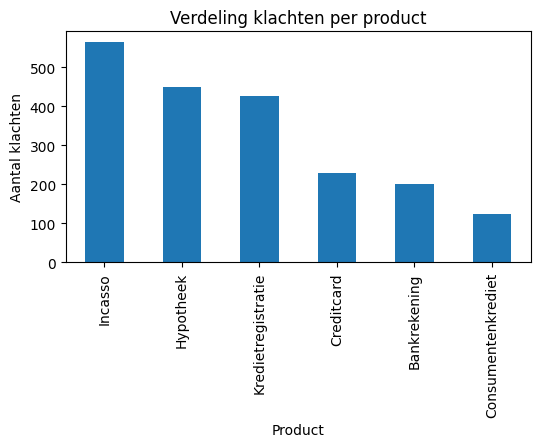

In [67]:
# Bar chart voor Product
plt.figure(figsize=(6,3))
train['Product'].value_counts().plot(kind="bar")
plt.title("Verdeling klachten per product")
plt.xlabel("Product")
plt.ylabel("Aantal klachten")
plt.show()

Incasso ontvangt de meeste klachten

### Analyse per product

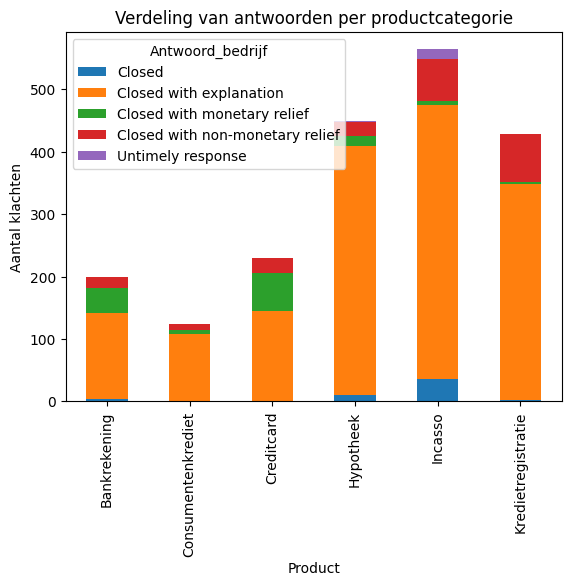

In [68]:
pd.crosstab(train["Product"], train["Antwoord_bedrijf"]).plot(kind="bar", stacked=True)
plt.title("Verdeling van antwoorden per productcategorie")
plt.ylabel("Aantal klachten")
plt.show()

### Analyse per specifieke feature

### Wordcloud per categorie

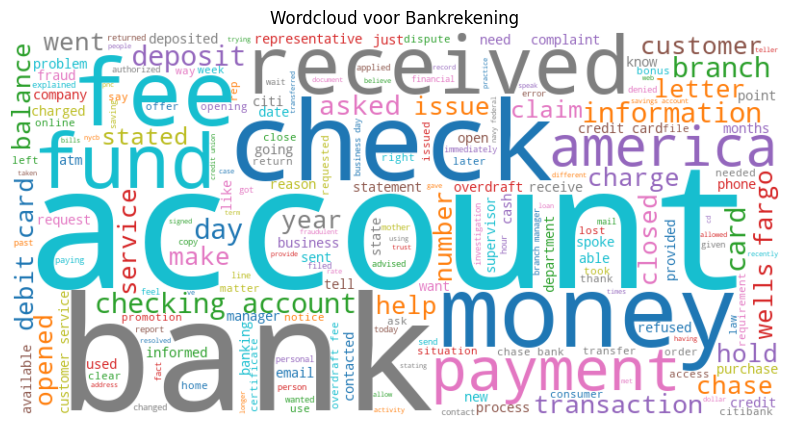

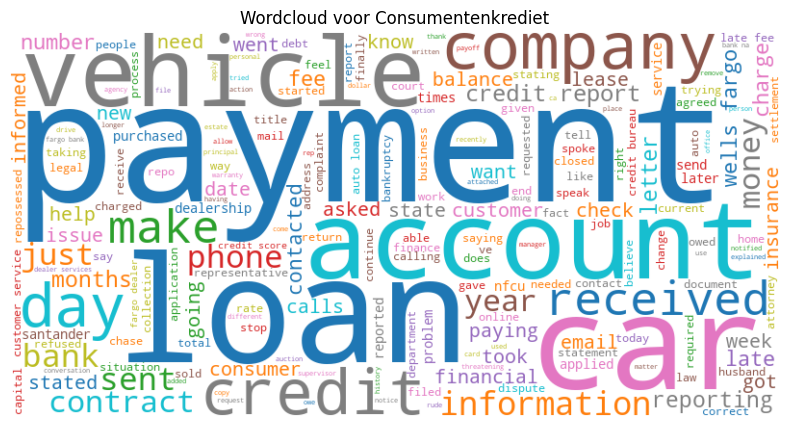

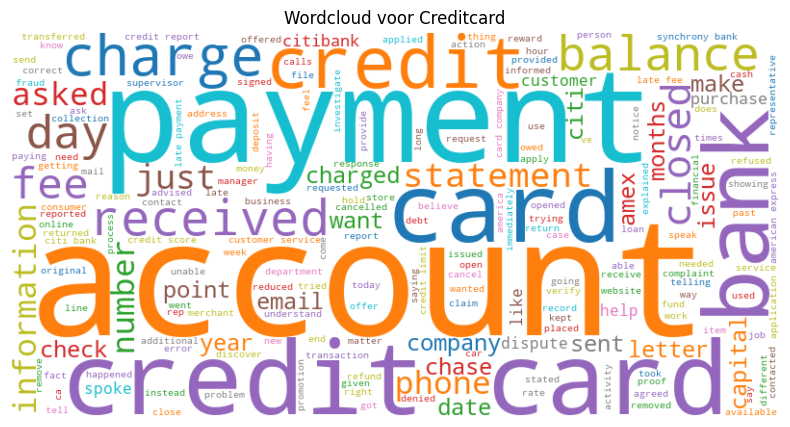

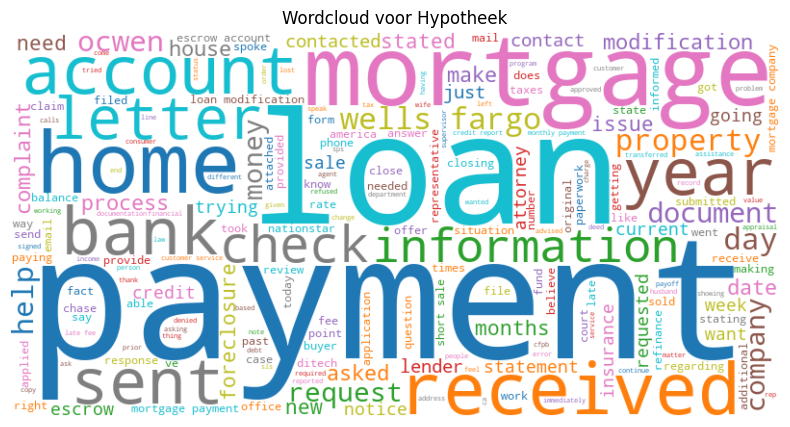

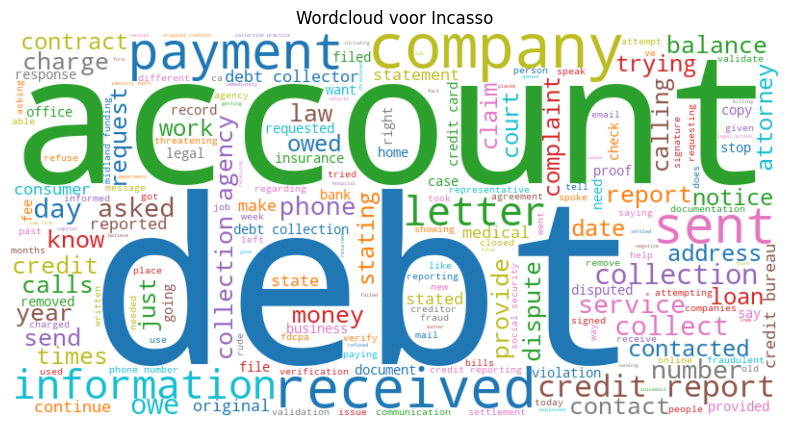

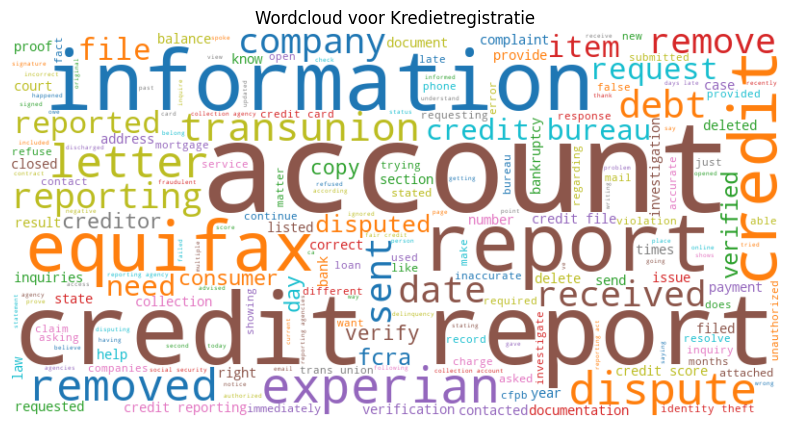

In [69]:
import pandas as pd, re, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from wordcloud import WordCloud


stopwoorden = list(set(ENGLISH_STOP_WORDS).union({
    'xxxx', 'xx', 'xxx', 'did', 'please', 'told', 'paid', 'called', 'time', 'said', 'month', 'pay',
    'a','b','c','d','e','f','g','h','i','j','k','l','m','n', 'o','p','q','r','s','t','u','v','w','x','y','z'
}))
#stopwoorden2 = set(stopwords.words("english"))

train["clean"] = train["Omschrijving"].fillna("").str.lower().str.replace(r'[^a-z\s]', ' ', regex=True)

vectorizer = TfidfVectorizer(stop_words=stopwoorden, max_features=1000)
tfidf = vectorizer.fit_transform(train["clean"])
woorden = vectorizer.get_feature_names_out()

train["Top_keywords"] = [
    [woorden[i] for i in tfidf[row].toarray()[0].argsort()[-5:][::-1]]
    for row in range(tfidf.shape[0])
]

for product, groep in train.groupby("Product"):
    tekst = " ".join(groep["clean"])
    wc = WordCloud(width=800, height=400, background_color="white",
                   stopwords=set(stopwoorden), colormap="tab10").generate(tekst)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Wordcloud voor {product}")
    plt.show()